<a href="https://colab.research.google.com/github/SauravSG/Deep-Learning/blob/main/CH_01_PyTorch_Workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **CH 01: PyTorch Workflow**

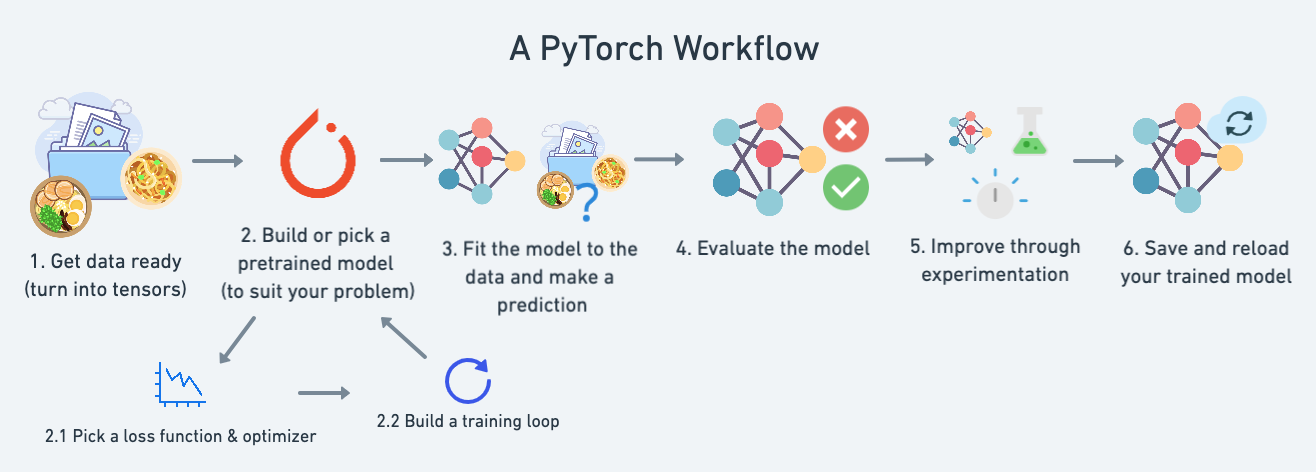

#### Topics:
1. Data (prepare and load)
2. Build model
3. Fitting (training) the model to data
4. Making predicitons and evaluating a model (inference)
5. Saving and loading a model
6. Putting it all together

In [ ]:
import torch
from torch import nn # nn - nn stands for neural network and this package contains the building blocks for creating neural networks in PyTorch
import matplotlib.pyplot as plt
import numpy as np
torch.__version__

'2.9.0+cu126'

#### 1. Data (prepare and load)

* Data can be anything in ML:
- Excel spreadsheet
- Images
- Videos
- Audio
- DNA or patterns
- Texts

ML is a game of two parts:
1. Getting data into numerical representation.
2. Build a model to learn patterns in that numerical representaion.

To showcase this, let's create some *known* data using the linear regression formula.

We'll use a linear regression formula to make a straight line with *known* **parameters** (things that can be learned by a model)

**Linear Regression** is a method of predicting the number(output) by fitting a best line through the data.

It assumes the relationship between input (like car age) and output (car price) can be approximated by a line:

 `y=mx+b`

where,

x is the independent variable (also called the input feature)

y is the dependent variable (also called the target / output)

m (slope) is how much the output changes when the input increases by one unit

b (bias/intercept) is the baseline value when the input is zero

m is calculated as:

`m=∑(x−xˉ)(y−yˉ)​/∑(x−xˉ)**2​`

and based on m, b is calculated.

In [ ]:
# create "known" parameters
weight = 0.7 # here weight means m only
bias = 0.3

# create
start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1) # turning a 1D tensor into a 2D tensor
y = weight * X + bias
print(X.ndim)
print(y.ndim)

2
2


In [ ]:
print(f'First 10 values of X: \n{X[:10]}', '\n', f'First 10 values of y: \n{y[:10]} \n', '\n', f'Length of X is: \n{len(X)}', '\n', f'Length of y is: \n{len(y)}')

First 10 values of X: 
tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800]]) 
 First 10 values of y: 
tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
        [0.3700],
        [0.3840],
        [0.3980],
        [0.4120],
        [0.4260]]) 
 
 Length of X is: 
50 
 Length of y is: 
50


What each dimension means

dim = 0 → moves down the rows
(how many samples → 50)

dim = 1 → moves across columns
(how many features → 1)

Why unsqueeze(1) changes the shape this way

Start with:

(50,)


Now do:

unsqueeze(1)


You’re saying:

“Insert a new dimension at position 1”

So the shape becomes:

(50, 1)


If instead you did:

unsqueeze(0)


Shape becomes:

(1, 50)


Visually:

unsqueeze(0) → one row, 50 columns

unsqueeze(1) → 50 rows, one column

#### Splitting our data into training and testing

Let's create a training and testing set with our data.

In [ ]:
# training and testing split

train_set = int(0.8 * len(X)) # taking 80% of the data (out of 50) for training
print(train_set)
X_train, y_train = X[:train_set], y[:train_set]
X_test, y_test = X[train_set:], y[train_set:]

print(len(X_train), len(y_train), len(X_test), len(y_test))


40
40 40 10 10


In [ ]:
def plot_predictions(train_data = X_train,
                     train_labels = y_train,
                     test_data = X_test,
                     test_labels = y_test,
                     predictions = None):
  '''
  plot training data, test data and compare predictions
  '''

  plt.figure(figsize=(10, 7))

  # plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label = "Training data")

  # plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Test data")

  #are there any predictions?
  if predictions is not None:

    #plot the predictions if they exist
    plt.scatter(test_data, predictions, c="r", s=6, label="Predicitons")

  # plot the legend
  plt.legend(prop={"size":14});

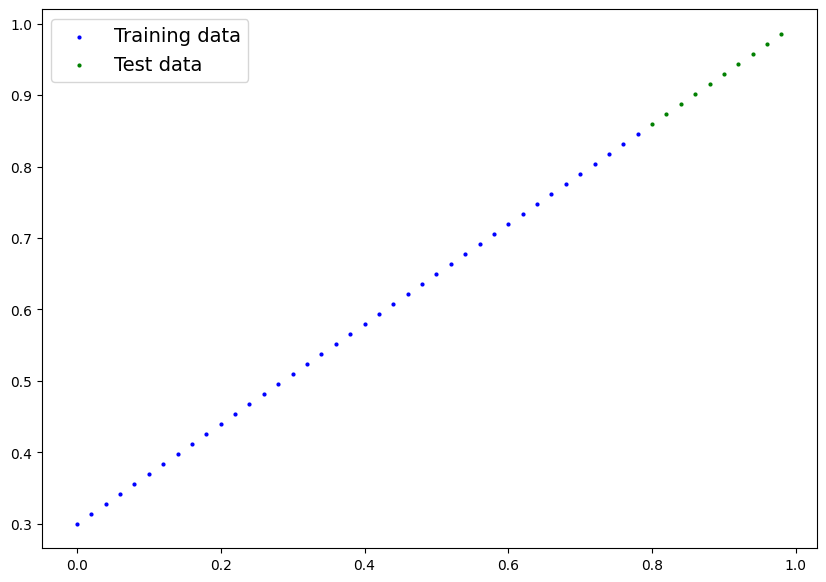

In [ ]:
plot_predictions()

#### 2. Build model

In [ ]:
from torch import nn

# create linear regression class
class LinearRegressionModel(nn.Module): # <- almost everthing in pytorch inherits from nn.Module
  def __init__(self): # <- defining constructor
    super().__init__() # <- Call parent class (nn.Module) constructor
    self.weights = nn.Parameter(torch.randn(1,
                                            requires_grad=True, # Tracks how changes to this value affect the error (so we can improve it during training) -> backproagation
                                            dtype=torch.float))

    self.bias = nn.Parameter(torch.randn(1,
                                         requires_grad = True,
                                         dtype=torch.float))

  def forward(self, x:torch.Tensor) -> torch.Tensor: # x is the input data of type tensor. And the function will also return a tensor type output aka using a type hint
    return self.weights * x + self.bias # this is a linear regression formula

    # withour type hint the fn can be written as:
    #   def forward(self, x):
    #     return self.weights * x + self.bias
  # this works too and type hint too. we used type hint to let us know what kind of input and what type of output it should return (tensor type)

`nn.Module`
What it is:

The base class for all neural network models in PyTorch
Think of it as a template/blueprint that all models inherit from

Significance:

- Provides essential functionality like parameter management, saving/loading models, and training capabilities
- By inheriting from nn.Module, your class automatically gets these superpowers
- Almost every PyTorch model starts with class MyModel(nn.Module)

`__init__(self)`
What it is:

The constructor method - runs automatically when you create a new instance of the class
self refers to the specific instance being created

Significance:

This is where you initialize/set up your model's parameters (weights, bias)
Gets called once when you do: model = LinearRegressionModel()

`super().__init__()`
What it is:

Calls the parent class's (nn.Module) constructor
super() means "the parent class"

Significance:

Required to properly initialize the nn.Module functionality
Without this, your model won't work correctly - PyTorch won't know about your parameters
Must be the first line in your __init__ method

`self.weights`
What it is:

The slope/coefficient in the linear equation y = mx + b (the "m")
Starts as a random value, gets adjusted during training

Significance:

This is what your model LEARNS

`self.bias`
What it is:

The y-intercept in the linear equation y = mx + b (the "b")
A constant value added to every prediction

Significance:

Allows the line to shift up or down, not just rotate
Without bias, your line must pass through the origin (0,0).

`nn.Parameter()`

In simple terms, nn.Parameter tells PyTorch: “this tensor is a learnable parameter of my model.”

It’s how you mark values like weights and biases so PyTorch knows they should be trained.

Automatically registers the parameter with the model.

`torch.randn(1, ...)`
What it is:

Creates a tensor with 1 random value from normal distribution

Role in code:

Provides random initialization for weights and bias
Random start is essential - starting at zero wouldn't allow learning
The 1 means we want a single random number

`requires_grad=True`
What it is:

Flag that enables gradient tracking for this parameter

Role in code:

Makes learning possible - tells PyTorch to track how this value affects the error
Enables backpropagation: calculates "if I change this value, how much does error change?"
Without it, the parameter stays frozen at its random initial value


`def forward(self, x: torch.Tensor) -> torch.Tensor:`
That line is defining the forward pass of a PyTorch model.
It tells PyTorch how input data flows through your model to produce output.

def forward(...)

This is a special method in nn.Module

PyTorch calls it automatically when you do:

`output = model(x)`


You do not call forward() directly in practice:

model.forward(x)  # ❌
model(x)          # ✅

def forward(self, x: torch.Tensor) -> torch.Tensor: defines how a PyTorch model transforms input tensors into output tensors during a forward pass.

nn.Module.forward() is intentionally empty/placeholder hence we don't do super().forward(x)

It's designed to raise an error if not overridden:

**Key Insight**: This code defines the model structure. Training (which adjusts weights/bias to minimize error) happens separately using an optimizer and loss function.

Image for reference:
https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/01-pytorch-linear-model-annotated.png

#### PyTorch model building essentials

* `torch.nn` -  is PyTorch's neural network module - a collection of tools and building blocks for creating machine learning models. Like a toolbox with everthing to build neural networks.

* `torch.nn.Parameter` - is a special wrapper that tells PyTorch: "This tensor is a learnable parameter that should be updated during training."

* `torch.nn.Module` - Base class for all NN modules. When we subclass it meaning creating a child class from it, we should use the parent's class **forward()** method in order to use it (not extend since it's an empty function) or like a replacement with our logic.

* `torch.optim` - contains optimizers - algorithms that update your model's parameters to reduce error during training. What Does It Do?
The optimizer's job:

      Look at the gradients (how to improve)
      Update the parameters (weights & bias)
      Make the model better at predictions

  Think of It Like:

      Model = Student taking a test
      Loss = Test score (how wrong you are)
      Gradients = Feedback on what to fix
      Optimizer = Study strategy to improve
  
* `def forward()` - all nn.Module subclasses requires to overwrite the forward fn. It defines what happens in the forward computation.

PyTorch Cheatsheet: https://pytorch-cn.com/tutorials/beginner/ptcheat.html

##### Checking the contents of our PyTorch model

Now the model is created, let's see what's inside.

So we can check our model parameters or what's inside our model using `.parameters()`

In [ ]:
# create a random seed - to keep the consistency of the random values
torch.manual_seed(42)

# create an instance of the model (subclass of nn.Module)
model_0 = LinearRegressionModel()

# check out the parameters
list(model_0.parameters())


[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
# list of named parameters - it maps each layer to its parameter tensor.
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
print(weight, bias) # the known ones where we defined these.

# Goal is to get the random parameters as close to known ones

0.7 0.3


Making prediction using `torch.inference_model()`

To check our model's predictive power, let's see how well it predicts `y_test` based on `X_test`

When we pass data through our model, it's going to run it through the `forward()` function. Here input/pass data is `x`.

In [ ]:
# Making prediction
with torch.inference_mode():
  y_pred = model_0(X_test) # will predict values for every row in X_test using the forward() forward pass.
  # can be written as but not recommended y_pred = model_0.forward(X_test) -> this tell the forward() to do the prediction using y=mx+b on the input X_test.

  print(f'Values predicts for every row/value in X_test: \n{y_pred}')

Values predicts for every row/value in X_test: 
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


In [ ]:
print(f'original y_test: \n {y_test}')

original y_test: 
 tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])


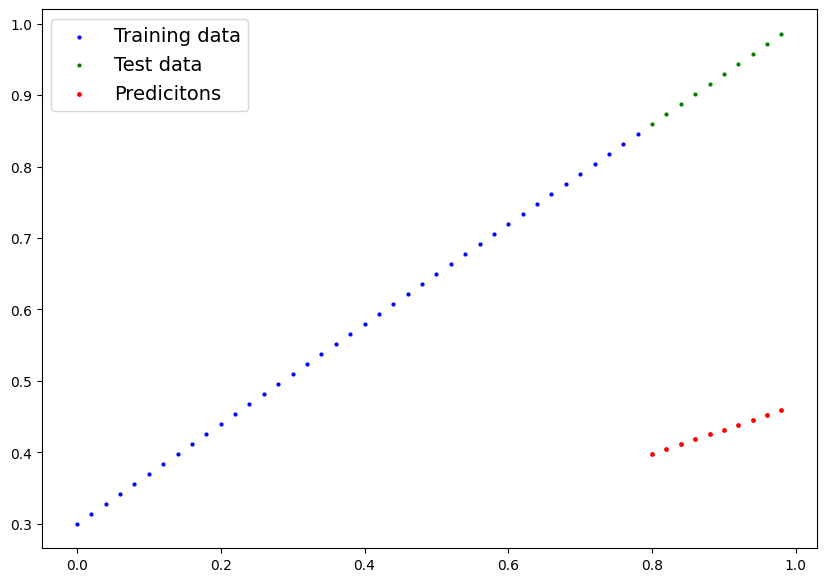

In [ ]:
plot_predictions(predictions=y_pred)

`inference_mode()` - tells PyTorch: "I'm just making predictions, not training - so skip all the gradient tracking stuff to save memory and speed up.
- this is achieved with the help of **context manager** - it is python pattern that automatically **turns off** and then **turns on** or rather does the **setup** and **clean up** for us. Like a smart light switch - Someone enters, do some work, someone leaves and light turns off automatically.
- with torch.inference_mode(): - This is just a "wrapper" for efficiency
It does NOT call forward() or make predictions itself
It's a context manager that changes PyTorch's behavior temporarily
Think of it like a "mode switch"

- What it does:

-  ✅ Tells PyTorch: "Don't track gradients for anything inside this block"
-  ✅ Saves memory (no need to store computation history)
-  ✅ Makes things faster
-  ✅ It's like saying: "We're just looking at results, not learning"

- The `y_pred = model_0(X_test)` can be written as but not recommended `y_pred = model_0.forward(X_test)` -> this tell the forward() to do the prediction using y=mx+b on the input X_test and this type of calling is done using **__call__()**. Reason is - pytorch does a lot of behind the scenes and this may cause some issue.

- `model_0(X_test)` - This calls **forward()** and makes predictions

- `model_0(X_test)` automatically calls `model_0.forward(X_test)`
- The forward() method computes: **self.weights * x + self.bias**
This is what actually makes the predictions

Hence we saw the red dots way away from the actual values.

#### 3. Train model

The whole idea of **training** is for a model to move from some *unknown* parameters to *known* parameters i.e. bringing the random/unknown weights and bias to the known weights (0.7) and bias (0.3).

Or in other words from a poor represenation of data to a better representation of data.

One way to measure how poor or how wrong the model's predictions are can be checked using **loss function**

* Note: Loss function may also be called as cost function or creiterion in different areas. We will refer to Loss function.

Things we need to train:

* **Loss function:** Fn to measure how wrong our model's predictions are to the ideal output. Lower the loss fuction the more better.

* **Optimizer:** Takes into account the loss of model and adjusts the model's parameters (e.g. weight & bias in our case) to improve the loss function.

Inside the optimizer we'll often have to set two parameters:
* `params` - the model parameters we'd like to optmize, for example `params = model_0.parameters()`

* `lr`(learning rate) - the learning rate is the hyperparameter that defines how big/small the optimizer changes the parameters with each step (a small lr results in small change and vice versa)

And specifically for PyTorch, we need:
* A training loop
* A testing loop

In [ ]:
# to see the parameters again:
print(list(model_0.parameters()), '\n')

print(model_0.state_dict())

[Parameter containing:
tensor([0.3367], requires_grad=True), Parameter containing:
tensor([0.1288], requires_grad=True)] 

OrderedDict({'weights': tensor([0.3367]), 'bias': tensor([0.1288])})


We will calculate the loss function using the Mean abs error:
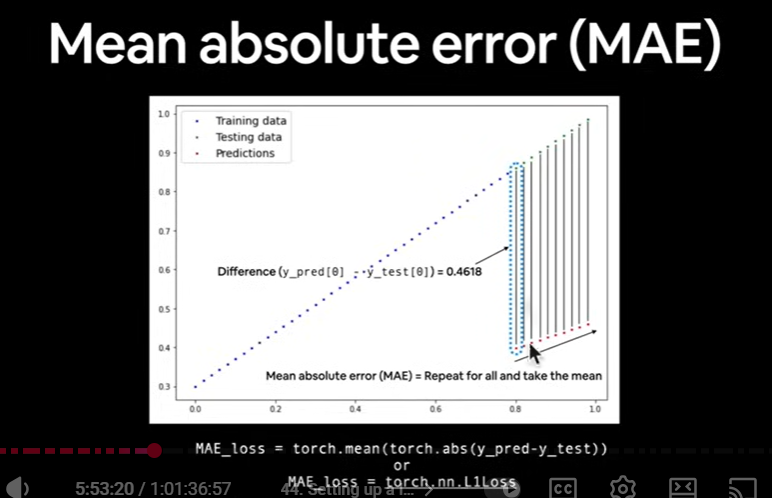

In [ ]:
# setup a loss fn
loss_fn = nn.L1Loss()
print(loss_fn)

# setup an optimizer (we will use SGD here - stochastic gradient descent)
optimizer = torch.optim.SGD(params = model_0.parameters(),
                            lr=0.01) # lr = learning rate = possibly the most imp hyperparamter you set
# smaller the learning rate, smaller the change in the parameter and vice versa


L1Loss()


How to know which loss fn and optimizer to use?

This is problem specific. But with experience we'll know.

for example,

-> For reggression powers like ours, a loss fn of nn.L1loss() and an optimizer like torch.optim.SGD() will suffice.

-> For classification (classifying dog or cat), loss fn og nn.BCELoss() (Binary cross entropy loss).

### 4. Building Training loop (and testing loop)

A couple of things we need in training loop:
0. Loop through data
1. forward pass (this involes data moving through model forward() - like data moving from input to ouput layer) to make prediciton on data - also called as forward propagation
2. Calculate the loss (compare forward pass predicitons to ground truth labels)
3. optimizer zero grad
4. Loss backward - move backwards through the network to calculate the gradients of each the parameters of our model with respect to the loss (**backpropagation**)
5. optimizer step - use the optimizer to adjust our model's parameter to try and improve the loss (**gradient descent**)

In [ ]:
torch.manual_seed(42)

# An epoch is one loop through the data...(this is the hyperparameter because we've set it ourselves)

epochs = 200

epoch_count = []
loss_count = []
test_loss_count = []

# 0. loop through the data
for epoch in range(epochs): # event though our epochs = 1 only

  # set the model to training mode
  model_0.train() # train mode in PyTorch sets all parameters that require gradients to require gradients

  # 1. forward pass
  y_pred = model_0(X_train)

  # 2. Calculate the loss
  loss = loss_fn(y_pred, y_train)
  print(f'Loss: {loss}')

  # 3. optimizer zero grad
  optimizer.zero_grad()

  # 4. perform backpropagation on the loss wrt the parameters of the model
  loss.backward()

  # 5. Step the optimizer (perform gradient descent)
  optimizer.step() # by default how the optimizer change will accumulate thorufh the loop so we have to zero them above in step 3 for the next interation fn the loop

  # testing
  model_0.eval() # turns off different settings in the model not needed for evaluation/testing (dropout /batch norms [will see later]). We are evaluating rather than training
  with torch.inference_mode(): # this turns off gradient tracking & a couple more things behind the scenes
    # 1. Do the forward pass - basically passing the input - this will call the model's implemented forward() method
    test_pred = model_0(X_test)

    # 2. calculate the loss
    test_loss = loss_fn(test_pred, y_test) # calculates how wrong the model's prediction are on the test dataset, lower is better

  # print what's happening...every 10th epoch -> display how the model is doing during training/testing every ~10 epochs
  if epoch % 10 == 0:
    epoch_count.append(epoch)
    loss_count.append(loss)
    test_loss_count.append(test_loss)
    print(f'\n Epoch: {epoch} | Loss: {loss} | Test loss: {test_loss}')

  # print out model state_dict()
    print(model_0.state_dict())

Loss: 0.31288138031959534

 Epoch: 0 | Loss: 0.31288138031959534 | Test loss: 0.48106518387794495
OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388])})
Loss: 0.3013603389263153
Loss: 0.28983935713768005
Loss: 0.2783183455467224
Loss: 0.26679736375808716
Loss: 0.2552763521671295
Loss: 0.24375534057617188
Loss: 0.23223432898521423
Loss: 0.22071333229541779
Loss: 0.20919232070446014
Loss: 0.1976713240146637

 Epoch: 10 | Loss: 0.1976713240146637 | Test loss: 0.3463551998138428
OrderedDict({'weights': tensor([0.3796]), 'bias': tensor([0.2388])})
Loss: 0.18615034222602844
Loss: 0.1746293306350708
Loss: 0.16310831904411316
Loss: 0.1515873372554779
Loss: 0.14006635546684265
Loss: 0.1285453587770462
Loss: 0.11702437698841095
Loss: 0.1060912236571312
Loss: 0.09681284427642822
Loss: 0.08908725529909134

 Epoch: 20 | Loss: 0.08908725529909134 | Test loss: 0.21729660034179688
OrderedDict({'weights': tensor([0.4184]), 'bias': tensor([0.3333])})
Loss: 0.08227583020925522
Loss: 0.07638

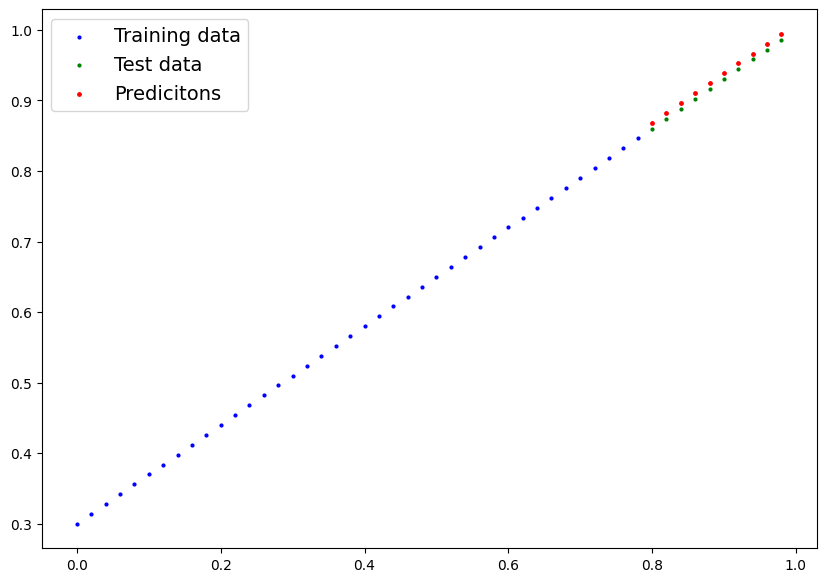

In [ ]:
plot_predictions(predictions=test_pred)

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [ ]:
print(epoch_count, '\n', loss_count, '\n', test_loss_count)

[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190] 
 [tensor(0.3129, grad_fn=<MeanBackward0>), tensor(0.1977, grad_fn=<MeanBackward0>), tensor(0.0891, grad_fn=<MeanBackward0>), tensor(0.0531, grad_fn=<MeanBackward0>), tensor(0.0454, grad_fn=<MeanBackward0>), tensor(0.0417, grad_fn=<MeanBackward0>), tensor(0.0382, grad_fn=<MeanBackward0>), tensor(0.0348, grad_fn=<MeanBackward0>), tensor(0.0313, grad_fn=<MeanBackward0>), tensor(0.0279, grad_fn=<MeanBackward0>), tensor(0.0245, grad_fn=<MeanBackward0>), tensor(0.0210, grad_fn=<MeanBackward0>), tensor(0.0176, grad_fn=<MeanBackward0>), tensor(0.0142, grad_fn=<MeanBackward0>), tensor(0.0107, grad_fn=<MeanBackward0>), tensor(0.0073, grad_fn=<MeanBackward0>), tensor(0.0039, grad_fn=<MeanBackward0>), tensor(0.0089, grad_fn=<MeanBackward0>), tensor(0.0089, grad_fn=<MeanBackward0>), tensor(0.0089, grad_fn=<MeanBackward0>)] 
 [tensor(0.4811), tensor(0.3464), tensor(0.2173), tensor(0.1446), tensor(0.1136), tens

In [ ]:

lost_values = np.array(torch.tensor(loss_count).numpy())

/tmp/ipython-input-3783925647.py:1: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  lost_values = np.array(torch.tensor(loss_count).numpy())


In [ ]:
print(epoch_count, '\n', lost_values, '\n', test_loss_count)

[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190] 
 [0.31288138 0.19767132 0.08908726 0.05314853 0.04543797 0.04167863
 0.03818933 0.0347609  0.03132383 0.0278874  0.02445896 0.02102021
 0.01758547 0.01415539 0.01071659 0.00728353 0.00385178 0.00893248
 0.00893248 0.00893248] 
 [tensor(0.4811), tensor(0.3464), tensor(0.2173), tensor(0.1446), tensor(0.1136), tensor(0.0992), tensor(0.0889), tensor(0.0806), tensor(0.0723), tensor(0.0647), tensor(0.0565), tensor(0.0482), tensor(0.0406), tensor(0.0323), tensor(0.0241), tensor(0.0165), tensor(0.0082), tensor(0.0050), tensor(0.0050), tensor(0.0050)]


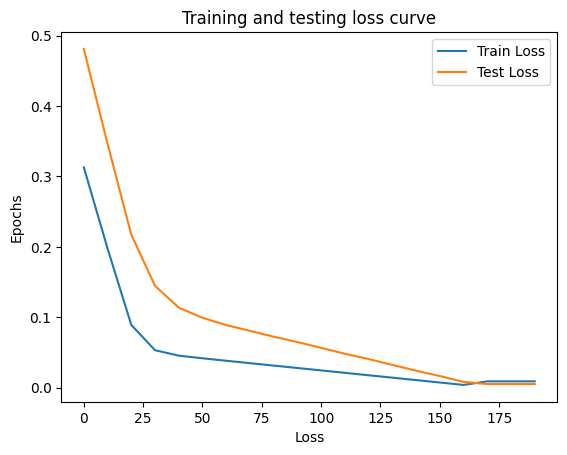

In [ ]:
# plot the loss curve
plt.plot(epoch_count, lost_values, label='Train Loss')
plt.plot(epoch_count, test_loss_count, label='Test Loss')
plt.title('Training and testing loss curve')
plt.xlabel('Loss')
plt.ylabel('Epochs')
plt.legend();

### 5. Saving a model in PyTorch

There are three ways to save model in YyTorch.

1. `torch.save()` - allows you to save a PyTorch object in python's pickle format

2. `torch.load()` - allows you to load a saved PyTorch object

3. `torch.nn.Module.load_state_dict()` - allows to load a model's saved state directory

In [ ]:
# saving our PyTorch model
from pathlib import Path

# 1. create model's directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path - to save it with some name
MODEL_NAME = '01_pytorch_workflow_model_0.pth'
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. save the model state dict
print(f'Saving model to: {MODEL_SAVE_PATH}')
torch.save(obj = model_0.state_dict(), f=MODEL_SAVE_PATH)

Saving model to: models/01_pytorch_workflow_model_0.pth


#### Loading the model:
since we saved our model's `state_dict()` rather than the entire model, we'll create a new instance of our model class and load the saved `state_dict()` into that.

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [ ]:
# To load in a state_dict(), we have to instantiate a new instance of model_0 class

loaded_model_0 = LinearRegressionModel()

#Load the saved state_dict() of model_0 (this will update the new instance with updated parameters)
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

<All keys matched successfully>

In [ ]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [ ]:
# make some prediction just to make sure with our loaded model

loaded_model_0.eval()
with torch.inference_mode():
  loaded_model_preds = loaded_model_0(X_test)

  print(loaded_model_preds)

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])


In [ ]:
# Compare loaded model preds with original model predictions
model_0.eval()

with torch.inference_mode():
  y_preds = model_0(X_test)
  print(y_preds)

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])


In [ ]:
y_preds == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

#### 6. Putting it all together

Let's go back through the steps above ans see it all in one place

In [ ]:
# import PyTorch
import torch
from torch import nn
import matplotlib.pyplot as plt

# check PyTorch version
torch.__version__

'2.9.0+cu126'

Create device-agnostic code.

This means if we have got access to GPU, our code will use it.

If no GPU is available, the code will default to using CPU.

In [ ]:
# Setup device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')

Using device: cuda


#### 6.1 Data

In [ ]:
# Create some data using the Linear Regression formula of y = weight * X + bias
weight = 0.8
bias = 0.2

# create range values
start = 0
end = 1
step = 0.02

# Create X (features) and y (labels)
X = torch.arange(start, end, step).unsqueeze(dim=1)
y = weight * X + bias

print(X[:10], '\n', y[:10])

tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800]]) 
 tensor([[0.2000],
        [0.2160],
        [0.2320],
        [0.2480],
        [0.2640],
        [0.2800],
        [0.2960],
        [0.3120],
        [0.3280],
        [0.3440]])


In [ ]:
# split data

train_split = int(0.8 * len(X))
print(f'The split or batch for training would be: {train_split} out of {len(X)}')

X_train_new, y_train_new = X[:train_split], y[:train_split] # <- takes the first 40 elements from X and 40 elements from y.

X_test_new, y_test_new = X[train_split:], y[train_split:]
print('\n Out of 50,')
print(f'\n {len(X_train_new)} features would go for training \n {len(y_train_new)} samples would go for training, \n {len(X_test_new)} features would go for testing, \n {len(y_test_new)} samples would go for testing')

The split or batch for training would be: 40 out of 50

 Out of 50,

 40 features would go for training 
 40 samples would go for training, 
 10 features would go for testing, 
 10 samples would go for testing


In [ ]:
# Plot the data
def plot_predictions_new(train_data = X_train_new,
                     train_labels = y_train_new,
                     test_data = X_test_new,
                     test_labels = y_test_new,
                     predictions = None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))  # a canvas of 10 inches wide, 7 inches tall

    # plot training data in blue
  plt.scatter(train_data, train_labels, c="b", s=4, label = "Training data")

  # plot test data in green
  plt.scatter(test_data, test_labels, c="g", s=4, label="Test data")

  #are there any predictions?
  if predictions is not None:

    #plot the predictions if they exist
    plt.scatter(test_data, predictions, c="r", s=6, label="Predicitons")

  # plot the legend
  plt.legend(prop={"size":14});

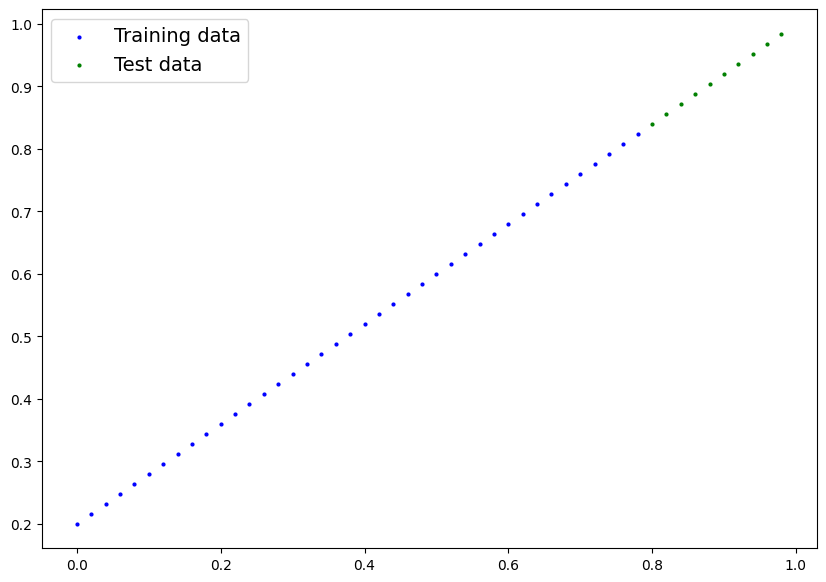

In [ ]:
plot_predictions_new()

6.2 Building a PyTorch Linear Model

In [ ]:
# Create a linear model by subclassing nn.Module
class LinearRegressionModelV2(nn.Module):

  def __init__(self):
    super().__init__()

    # Use nn.Linear() for creating the model parameters - Linear() because our data is linear

    self.linear_layer = nn.Linear(in_features=1,
                                  out_features=1) # <- in_feature and out_feature = 1 means one input  from X and y and one output. each row is single element hence that's why 1

  def forward(self, x:torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x) # since we are using the linear_layer from Linear(), the formula is automatically computed

# Set manual seed
torch.manual_seed(42)

model_1 = LinearRegressionModelV2()
print(model_1, '\n', model_1.state_dict())

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
) 
 OrderedDict({'linear_layer.weight': tensor([[0.7645]]), 'linear_layer.bias': tensor([0.8300])})


In [ ]:
# check the model current device
next(model_1.parameters()).device # we are checking where our parameters lives. By default or here the answer would be 'cpu'

device(type='cpu')

In [ ]:
# Set the model to use the target device
model_1.to(device)
next(model_1.parameters()).device # now this will tell our parameters lives in 'gpu'

device(type='cuda', index=0)

6.3 Training

We need:
* loss function
* optimizer
* training loop
* testing loop

In [ ]:
# Set up the loss function
new_loss_func = nn.L1Loss()

# Setup our optimizer
optimizer = torch.optim.SGD(params = model_1.parameters(),
                            lr=0.01) # params is like the parameters we want to optimize

In [ ]:
# let's write the training loop

torch.manual_seed(42)

epochs = 200

# put data on target device or else it will through error of device incompatibility
X_train_new, y_train_new = X_train_new.to(device), y_train_new.to(device)
X_test_new, y_test_new = X_test_new.to(device), y_test_new.to(device)

for epoch in range(epochs):
  model_1.train()  # setting the model to train

  # 1. do the forward pass
  y_pred_new = model_1(X_train_new)

  # 2. calculating loss fn
  loss_new = new_loss_func(y_pred_new, y_train_new)

  # 3. optimize
  optimizer.zero_grad() # we want every epoch to start from zero...i guess

  # 4. perform backpropagation
  loss_new.backward()

  # 5. optimizer step
  optimizer.step()

  # Testing
  model_1.eval()
  with torch.inference_mode():
    test_pred_new = model_1(X_test_new)

    test_loss_new = new_loss_func(test_pred_new, y_test_new)

    # print what's happening

    if epoch % 10 == 0:
      print(f'Epoch is: {epoch} | Loss is: {loss_new} | Test loss is: {test_loss_new}')



Epoch is: 0 | Loss is: 0.6161779165267944 | Test loss is: 0.5849762558937073
Epoch is: 10 | Loss is: 0.5009680986404419 | Test loss is: 0.45026642084121704
Epoch is: 20 | Loss is: 0.3857581913471222 | Test loss is: 0.3155565857887268
Epoch is: 30 | Loss is: 0.2705483138561249 | Test loss is: 0.180846706032753
Epoch is: 40 | Loss is: 0.15533843636512756 | Test loss is: 0.046136897057294846
Epoch is: 50 | Loss is: 0.05875825881958008 | Test loss is: 0.06886561214923859
Epoch is: 60 | Loss is: 0.04580378159880638 | Test loss is: 0.09473040699958801
Epoch is: 70 | Loss is: 0.041819483041763306 | Test loss is: 0.09405827522277832
Epoch is: 80 | Loss is: 0.03831038996577263 | Test loss is: 0.08853326737880707
Epoch is: 90 | Loss is: 0.034879546612501144 | Test loss is: 0.08094760775566101
Epoch is: 100 | Loss is: 0.03144557774066925 | Test loss is: 0.07267507165670395
Epoch is: 110 | Loss is: 0.028006771579384804 | Test loss is: 0.06440252810716629
Epoch is: 120 | Loss is: 0.0245776120573282

In [ ]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7987]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.2095], device='cuda:0'))])

In [ ]:
print(weight, bias)

0.8 0.2


6.4 Making and evaluating predictions

In [ ]:
# turn model into evaluation mode
model_1.eval()

# make prediction on the test data
with torch.inference_mode():
  y_preds_new = model_1(X_test_new)


In [ ]:
print(y_pred_new)

tensor([[0.1995],
        [0.2154],
        [0.2313],
        [0.2472],
        [0.2631],
        [0.2790],
        [0.2949],
        [0.3108],
        [0.3267],
        [0.3426],
        [0.3585],
        [0.3744],
        [0.3903],
        [0.4061],
        [0.4220],
        [0.4379],
        [0.4538],
        [0.4697],
        [0.4856],
        [0.5015],
        [0.5174],
        [0.5333],
        [0.5492],
        [0.5651],
        [0.5810],
        [0.5969],
        [0.6128],
        [0.6287],
        [0.6446],
        [0.6605],
        [0.6764],
        [0.6923],
        [0.7082],
        [0.7241],
        [0.7400],
        [0.7558],
        [0.7717],
        [0.7876],
        [0.8035],
        [0.8194]], device='cuda:0', grad_fn=<AddmmBackward0>)


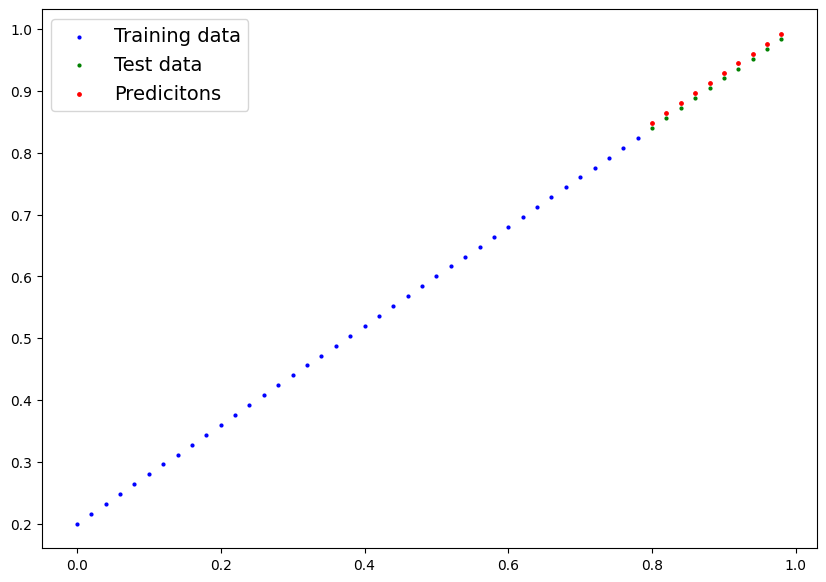

In [ ]:
plot_predictions_new(predictions=y_preds_new.cpu())

6.5 Saving and loading our trained model

In [ ]:
from pathlib import Path

# 1. create model directory
MODEL_PATH = Path('models')
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. create model save path
MODEL_NAME = '01_pytorch_workflow_model_1.pth'
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. save the model state dict
print(f'Saving model to: {MODEL_SAVE_PATH}')
torch.save(obj=model_1.state_dict(), f=MODEL_SAVE_PATH)


Saving model to: models/01_pytorch_workflow_model_1.pth


In [ ]:
# Load a PyTorch model

# create new instance of LR model V2
loaded_model_1 = LinearRegressionModelV2()

# Load the saved model state_dict()
loaded_model_1.load_state_dict(torch.load(f=MODEL_SAVE_PATH))

# put target model to device
loaded_model_1.to(device)

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [ ]:
next(loaded_model_1.parameters()).device

device(type='cuda', index=0)

In [ ]:
loaded_model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.7987]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.2095], device='cuda:0'))])

In [ ]:
# evaluate loaded model

loaded_model_1.eval()
with torch.inference_mode():
  loaded_model_preds = loaded_model_1(X_test_new)

print(loaded_model_preds)

# Comparing
print(loaded_model_preds == y_preds_new)

tensor([[0.8484],
        [0.8644],
        [0.8804],
        [0.8964],
        [0.9123],
        [0.9283],
        [0.9443],
        [0.9603],
        [0.9762],
        [0.9922]], device='cuda:0')
tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')


## Exercises

GRADIENT DESCENT FULL NOTES PLAIN TEXT VERSION

KEY TERMS DEFINITIONS AND ROLES

1 Parameter

Definition
A parameter is a value that learning updates to reduce the loss.

Role
Parameters are what the model learns.

2 Loss function

Definition
A loss function measures how wrong the current parameters are.

Role
It defines what learning is trying to minimize.

Example
Loss L(x) = x * x

3 Loss value

Definition
The numerical output of the loss function for a given parameter value.

Role
It tells how good or bad the current parameters are.

Example
If x = 4 then loss = 16

4 Gradient

Definition
The gradient is the rate at which the loss changes when the parameter changes.

Role
It tells the direction and size of change needed to reduce the loss.

Example
For L(x) = x * x
Gradient = 2 * x

5 Backpropagation

Definition
Backpropagation is the process of computing gradients of the loss with respect to parameters.

Role
It calculates gradients but does not update parameters.

Example
For L(x) = x * x
Backpropagation gives gradient = 2 * x

6 Direction of descent

Definition
The direction opposite to the gradient.

Role
Moving opposite to the gradient reduces the loss.

7 Learning rate

Definition
A small positive value that controls how big each update step is.

Role
It controls how fast parameters change.

8 Gradient descent

Definition
Gradient descent is a method that updates parameters using gradients.

Update rule
New parameter = old parameter - learning rate * gradient

Role
It reduces the loss step by step.

9 Optimizer

Definition
An optimizer is the component that applies gradient descent using computed gradients.

Role
It updates parameters and manages learning.

SIMPLE MATHS EXAMPLE USING ALL CONCEPTS

Loss function
L(x) = x * x

Initial parameter
x = 4

Initial loss
Loss = 16

Gradient computation
Gradient = 2 * x
At x = 4 gradient = 8

Learning rate
Learning rate = 0.1

Optimizer update
New x = 4 - 0.1 * 8
New x = 3.2

New loss
Loss = 3.2 * 3.2 = 10.24

Loss reduced from 16 to 10.24

This process repeats until gradient = 0
At gradient = 0 the loss is minimized

HOW THIS WORKS IN MACHINE LEARNING

1 Parameters are initialized
2 Forward pass computes predictions
3 Loss function measures error
4 Backpropagation computes gradients
5 Optimizer reads gradients
6 Gradient descent updates parameters
7 Updated parameters are used next iteration
8 Process repeats until loss stops decreasing

FINAL SUMMARY

Learning minimizes a loss by computing gradients using backpropagation and updating parameters using an optimizer.

In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt

In [ ]:
# Create a straight line dataset using the linear regression formula (weight * X + bias).
#  Set weight=0.3 and bias=0.9 there should be at least 100 datapoints total.
weight = 0.3
bias = 0.9

start = 0
end = 1
split = 0.01
X = torch.arange(start, end, split).unsqueeze(dim=1) # we are creating the tensor X with total of 100 elements with 100 rows and 1 column -> unsqueezed to 2D
y = weight * X + bias # same as X. 2D dim.
print(X[:10], '\n', y[:10]) # printing the first 10 values of X and y

# Split the data into 80% training, 20% testing.
train_split = int(0.8 * len(X)) # train_split count -> 80
print(f'The split for training would be: {train_split} out of {len(X)}')
X_trainv2, y_trainv2 = X[:train_split], y[:train_split] # training amount of X and y will be 80
X_testv2,  y_testv2 = X[train_split:], y[train_split:] # testing amount of X and y will be 20
print(len(X_trainv2), len(y_trainv2), len(X_testv2), len(y_testv2)) # confirming the above split
# Plot the training and testing data so it becomes visual.
def plot_predictions_v2(training_features = X_trainv2,
                        training_labels = y_trainv2,
                        testing_features = X_testv2,
                        testing_labels = y_testv2,
                        predictionsv2 = None):

  data_figure = plt.figure(figsize=(10, 7)) # a canvas of 10 inches wide 7 inches tall

  plt.scatter(training_features, training_labels, c='b', s=4, label='Training data')

  plt.scatter(testing_features, testing_labels, c='g', s=4, label='Testing data')

  if predictionsv2 is not None:
    plt.scatter(testing_features, predictionsv2, c='r', s=6, label='Predictions')

  plt.legend(prop={'size':14}) # size of the legend or inshort, text.



tensor([[0.0000],
        [0.0100],
        [0.0200],
        [0.0300],
        [0.0400],
        [0.0500],
        [0.0600],
        [0.0700],
        [0.0800],
        [0.0900]]) 
 tensor([[0.9000],
        [0.9030],
        [0.9060],
        [0.9090],
        [0.9120],
        [0.9150],
        [0.9180],
        [0.9210],
        [0.9240],
        [0.9270]])
The split for training would be: 80 out of 100
80 80 20 20


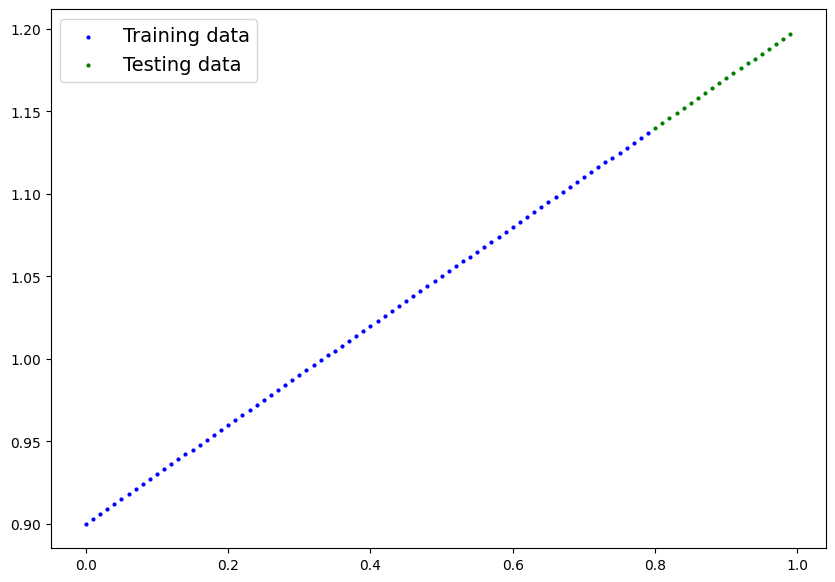

In [ ]:
plot_predictions_v2() # plotting the training and test before the prediction.

In [ ]:
# Build a PyTorch model by subclassing nn.Module.
class LinearRegressionModelV3(nn.Module):  # inheriting the nn.Module class
  def __init__(self): # creating a constructor so it will be called when a new instance of the class is created.
    super().__init__() # using nn.Module's constructor to Enables .parameters(), .state_dict(), .train(), .eval() methods. Registers parameters automatically.
# Inside should be a randomly initialized nn.Parameter() with requires_grad=True, one for weights and one for bias.
    self.weight = nn.Parameter(torch.randn(1,
                                      requires_grad = True,
                                      dtype = torch.float))  # creating the first learnable parameter of single element and enabling the gradient so the change is values can be tracked and it's type would be float32

    self.bias = nn.Parameter(torch.randn(1,
                                        requires_grad = True,
                                        dtype = torch.float)) # same as self.weight

# Implement the forward() method to compute the linear regression function you used to create the dataset in 1.

  def forward(self, x:torch.Tensor) -> torch.Tensor:
    return self.weight * x + self.bias  # overwriting nn.Module's forward() method in order to process the input and computing the linear regression's formula for prediction

# Once you've constructed the model, make an instance of it and check its state_dict().
model_2 = LinearRegressionModelV3() # a  new instance of the class
print(model_2, '\n', model_2.state_dict()) # state_dict will print the parameter's name and it's value

# Note: If you'd like to use nn.Linear() instead of nn.Parameter() you can.

LinearRegressionModelV3() 
 OrderedDict({'weight': tensor([-0.5476]), 'bias': tensor([0.0517])})


In [ ]:
# Create a loss function and optimizer using nn.L1Loss() and torch.optim.SGD(params, lr) respectively.
loss_func = nn.L1Loss() # a loss function to calculate the difference/loss between the predicted value and actual value in X_train which will be done in further steps

# Set the learning rate of the optimizer to be 0.01 and the parameters to optimize should be the model parameters from the model you created in 2.
optimizer_new = torch.optim.SGD(params = model_2.parameters(),
                            lr=0.01)  # creating an optimizer using the SGD optimizer. SGD (Stochastic Gradient Descent) is the algorithm that updates parameters. It does:
                                      # parameter = parameter - learning_rate × gradient

torch.manual_seed(42)  # setting a seed to a fixed arbitary values so the random values would be same

# Write a training loop to perform the appropriate training steps for 300 epochs.
epochs = 300 # epochs/epoch is like a session so here we are creating 300 sessions to bring the random value as close as possible to the actual value

for epoch in range(epochs): # beginning the trainin and evaluation/testing for each session.

# <--------Training-------->

  model_2.train()  # setting the model in a training mode.

  y_predv2_1 = model_2(X_trainv2)  # making predictions using the forward() where X_trainv2 tensor is the input. we will get the y_predv2_1 as a tensor only.

  train_loss = loss_func(y_predv2_1, y_trainv2)  # once the values for X_trainv2 are predicted, now we will calculate the loss we had between the predicted value and the actual value of those features
  print(train_loss.item())
  optimizer_new.zero_grad()  # Clear old gradients from previous iteration so they don't accumulate.

  train_loss.backward()  # Calculate gradients (how to adjust parameters) to reduce the loss"
                         # The backward() itself doesn't make you "come closer" - it just calculates the directions. The optimizer.step() is what actually moves you closer.

  optimizer_new.step()  # actually taking the step as per the backward() value

# <--------Evaluating-------->
  model_2.eval()  # based on the training, now we do it's evaluation by putting it into evaluation mode

  with torch.inference_mode(): # using the context manager, we are turning off the gradient tracking along with the use of inference_mode()
    # The training loop should test the model on the test dataset every 20 epochs.
    test_predv2 = model_2(X_testv2) # now we are predicting against the X_test as in predicting the values against the testing features

    test_lossv2 = loss_func(test_predv2, y_testv2)  # calculating the loss

    if epoch % 20 == 0:
      print(f'epoch : {epoch} | loss : {train_loss} | test loss : {test_lossv2}')

1.1831399202346802
epoch : 0 | loss : 1.1831399202346802 | test loss : 1.5934045314788818
1.1715797185897827
1.1600193977355957
1.1484591960906982
1.1368988752365112
1.1253387928009033
1.1137783527374268
1.1022181510925293
1.0906579494476318
1.0790977478027344
1.0675373077392578
1.0559771060943604
1.0444170236587524
1.0328565835952759
1.021296501159668
1.009736180305481
0.9981757998466492
0.9866156578063965
0.9750553965568542
0.963495135307312
0.9519349336624146
epoch : 20 | loss : 0.9519349336624146 | test loss : 1.3226995468139648
0.9403745532035828
0.9288144111633301
0.9172541499137878
0.9056938886642456
0.8941336870193481
0.8825734853744507
0.8710132837295532
0.8594529032707214
0.8478926420211792
0.8363324999809265
0.8247722387313843
0.8132119178771973
0.8016517758369446
0.7900915741920471
0.7785312533378601
0.7669709920883179
0.7554107904434204
0.7438505291938782
0.7322902679443359
0.7207300662994385
epoch : 40 | loss : 0.7207300662994385 | test loss : 1.051994800567627
0.70916980

In [ ]:
print(X_trainv2.shape, X.shape, y_predv2_1.shape) # just checking the shape

torch.Size([80, 1]) torch.Size([100, 1]) torch.Size([80, 1])


In [ ]:
model_2.state_dict() # printing the closest predicted values of weight and bias for the model_2

OrderedDict([('weight', tensor([0.3069])), ('bias', tensor([0.9035]))])

In [ ]:
print(weight, bias)

0.3 0.9


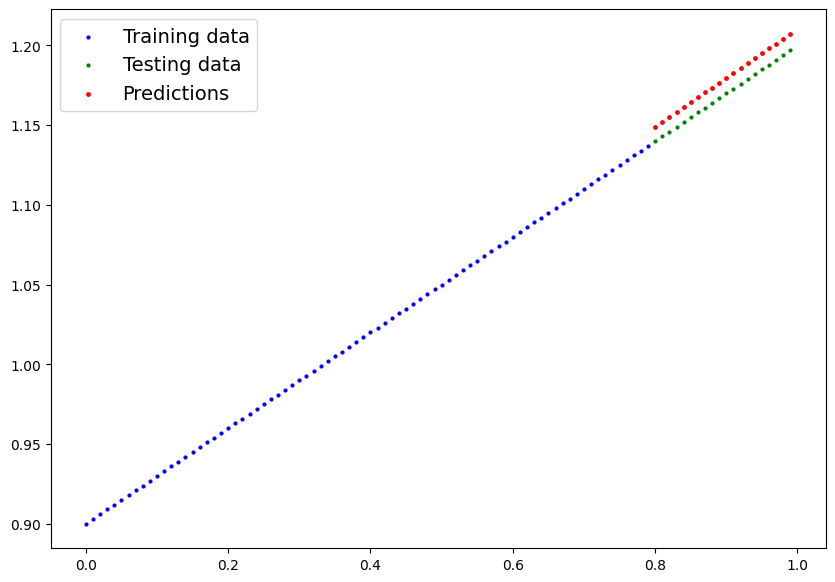

In [ ]:
# Make predictions with the trained model on the test data
plot_predictions_v2(predictionsv2=test_predv2)  # plotting the graph between how closely the predicted values were to the actual values

In [ ]:
# saving the model
from pathlib import Path

# create model path directory
MODEL_PATH = Path('models')
MODEL_PATH.mkdir(parents = True, exist_ok = True)

# create save model path
MODEL_NAME = '01_pytorch_workflow_model_2.pth'
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# save the model state_dict
print(f'Saving the model to: {MODEL_SAVE_PATH}')
torch.save(obj=model_2.state_dict(), f=MODEL_SAVE_PATH)

Saving the model to: models/01_pytorch_workflow_model_2.pth


In [ ]:
# load it in back
# creating a new instance of the model
model_3 = LinearRegressionModelV3()

model_3.load_state_dict(torch.load(MODEL_SAVE_PATH))

model_3.state_dict()

OrderedDict([('weight', tensor([0.3069])), ('bias', tensor([0.9035]))])

In [ ]:
# evaluate the model
model_3.eval()

with torch.inference_mode():

  model_3_preds = model_3(X_testv2)

print(model_3_preds == test_predv2)

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])


MAPPING GRADIENT DESCENT TEACHING TO PYTORCH CODE

1 Parameters

Math concept
Parameters are the values that learning updates

PyTorch mapping
Parameters are created inside the model
They use nn Parameter or layers like nn Linear
requires_grad = True tells PyTorch to compute gradients

What happens next
PyTorch tracks all operations involving these parameters

2 Forward pass

Math concept
Use parameters to compute predictions

PyTorch mapping
y_pred = model(X)

What happens next
Predictions are computed
PyTorch builds a computational graph

3 Loss function

Math concept
Loss measures how wrong predictions are

PyTorch mapping
loss = loss_function(y_pred y_true)

What happens next
Loss becomes a single scalar value
This value will be minimized

4 Backpropagation

Math concept
Compute gradients of loss with respect to parameters

PyTorch mapping
loss.backward()

What happens next
Gradients are computed
Each parameter gets a gradient stored in parameter.grad
Parameters are not updated yet

5 Clear old gradients

Math concept
Gradients must not accumulate across steps

PyTorch mapping
optimizer.zero_grad()

What happens next
Old gradients are cleared before next update

6 Optimizer step

Math concept
Apply gradient descent update

Update rule
New parameter = old parameter - learning rate * gradient

PyTorch mapping
optimizer.step()

What happens next
Optimizer reads parameter.grad
Parameters are updated in place
Learning happens here

7 Training loop

Math concept
Repeat gradient descent updates multiple times

PyTorch mapping
for epoch in range(epochs)

What happens next
Each iteration improves parameters gradually

8 Evaluation mode

Math concept
Evaluate without updating parameters

PyTorch mapping
model.eval()
with torch.inference_mode()

What happens next
No gradients are computed
Parameters remain unchanged
Evaluation is faster

FULL FLOW SUMMARY

Initialize parameters
Run forward pass
Compute loss
Run backward to compute gradients
Clear old gradients
Optimizer updates parameters
Repeat until loss converges

ONE LINE MENTAL MODEL

Forward computes predictions
Loss measures error
Backward computes gradients
Optimizer updates parameters
Loop repeats until learning completes

IN SHORT:
Imagine training a student:

1. Student answers → forward

2. Teacher checks → loss

3. Teacher explains mistake → backprop

4. Student corrects approach → optimizer

5. Correction intensity → learning rate